<a href="https://colab.research.google.com/github/Sarya92/Colab_Kaggle/blob/main/TITANIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# Basado en Competición de Titanic https://youtu.be/8yZMXCaFshs?si=SndfbHVH9fHqX3Rl

In [44]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
#Importamos la librería pandas para manipular tablas de datos y cargamos los archivos CSV.

In [48]:
# 1. Cargar los datos que subiste manualmente
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")
#El conjunto de entrenamiento sirve para que el modelo aprenda, y el de prueba para validar qué tan bien predice.
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [49]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [50]:
# 2. Definir el objetivo (lo que queremos predecir)
y = train_data["Survived"]
#Queremos averiguar la tasa de supervivencia

In [51]:
# 3. Seleccionar las variables (características)
features = ["Pclass", "Sex", "SibSp", "Parch"]
#No todos los datos son útiles para predecir. Aquí elegimos las columnas que creemos que influyeron en la supervivencia, como la clase del pasajero o el género.

In [52]:
# 4. Convertir variables de texto a números (One-Hot Encoding)
# Esto convierte "Sex" en columnas de 0 y 1 para que el modelo lo entienda
X = pd.get_dummies(train_data[features])
X_test = pd.get_dummies(test_data[features])
#Las maquinas no entienden palabras como "female", mejor números. get_dummies convierte categorías de texto en columnas de ceros y unos.

In [53]:
# 5. Crear y entrenar el modelo
# Un Random Forest combina múltiples árboles de decisión para mayor precisión
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X, y)
#Usamos un "Random Forest", que es un conjunto de muchos árboles de decisión. Cada árbol analiza los datos de forma distinta y, al final, el modelo elige la respuesta más votada entre todos ellos.

RandomForestClassifier(max_depth=5, random_state=1)

In [54]:
# 6. Realizar las predicciones sobre los datos de prueba
predictions = model.predict(X_test)
#Aplicamos el modelo ya entrenado sobre los datos de los pasajeros de los que NO sabemos el destino (test_data) y guardamos el resultado en un archivo nuevo.

In [55]:
# 7. Crear el archivo final de resultados
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)

print("¡Listo! El archivo 'submission.csv' se ha generado en tu carpeta de archivos.")

¡Listo! El archivo 'submission.csv' se ha generado en tu carpeta de archivos.


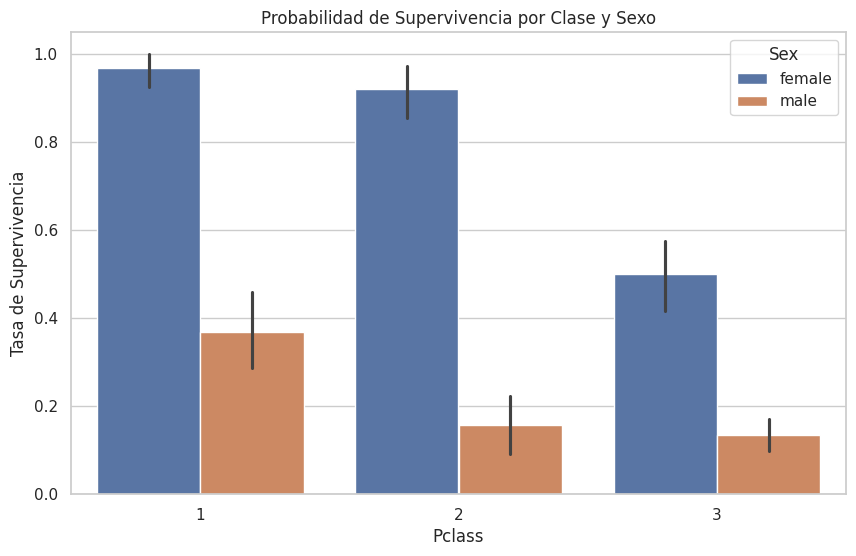

In [56]:
#Supervivencia por Género y Clase
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")

# Gráfico de barras: Clase vs Supervivencia (separado por Sexo)
plt.figure(figsize=(10, 6))
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=train_data)
plt.title("Probabilidad de Supervivencia por Clase y Sexo")
plt.ylabel("Tasa de Supervivencia")
plt.show()

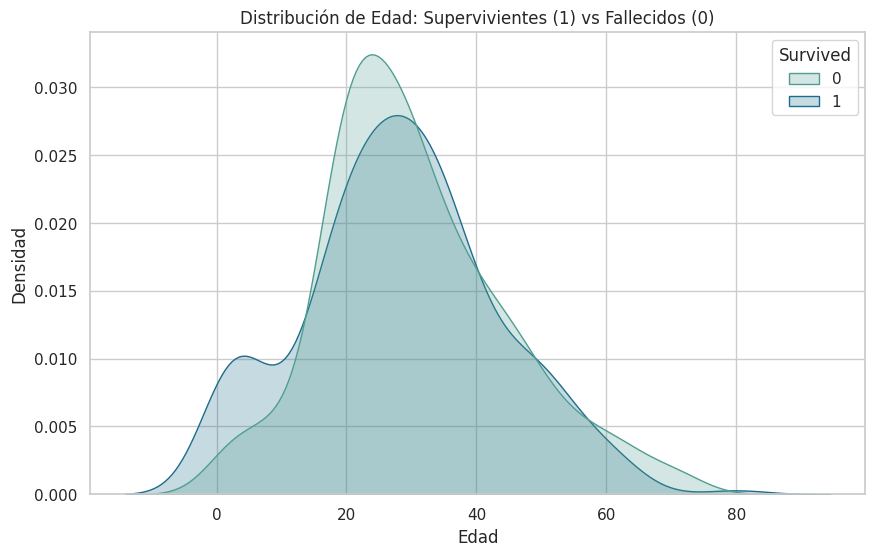

In [57]:
#Distribución de Edad y Supervivencia
# Gráfico de densidad para la Edad
plt.figure(figsize=(10, 6))
sns.kdeplot(data=train_data, x="Age", hue="Survived", fill=True, common_norm=False, palette="crest")
plt.title("Distribución de Edad: Supervivientes (1) vs Fallecidos (0)")
plt.xlabel("Edad")
plt.ylabel("Densidad")
plt.show()

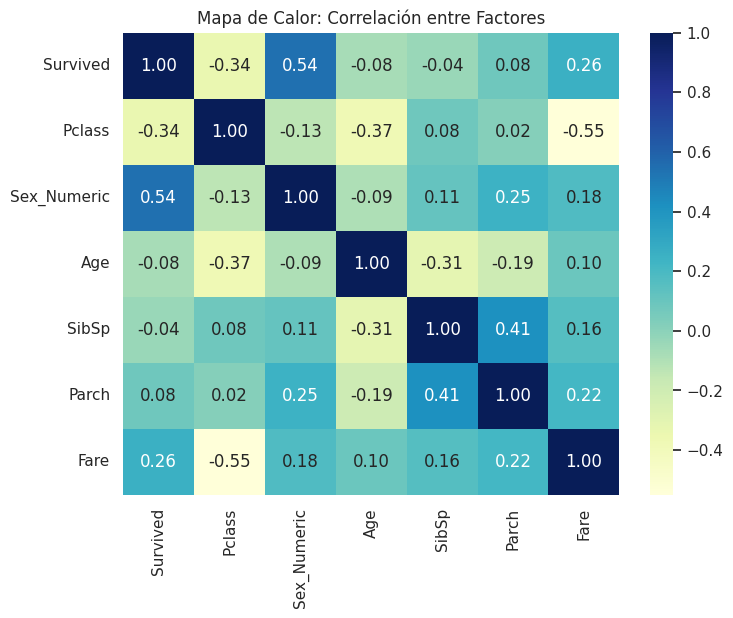

In [58]:
#Matriz de Correlación
# Primero convertimos Sex a números para poder correlacionar
train_data['Sex_Numeric'] = train_data['Sex'].map({'female': 1, 'male': 0})

plt.figure(figsize=(8, 6))
correlation_matrix = train_data[['Survived', 'Pclass', 'Sex_Numeric', 'Age', 'SibSp', 'Parch', 'Fare']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Mapa de Calor: Correlación entre Factores")
plt.show()

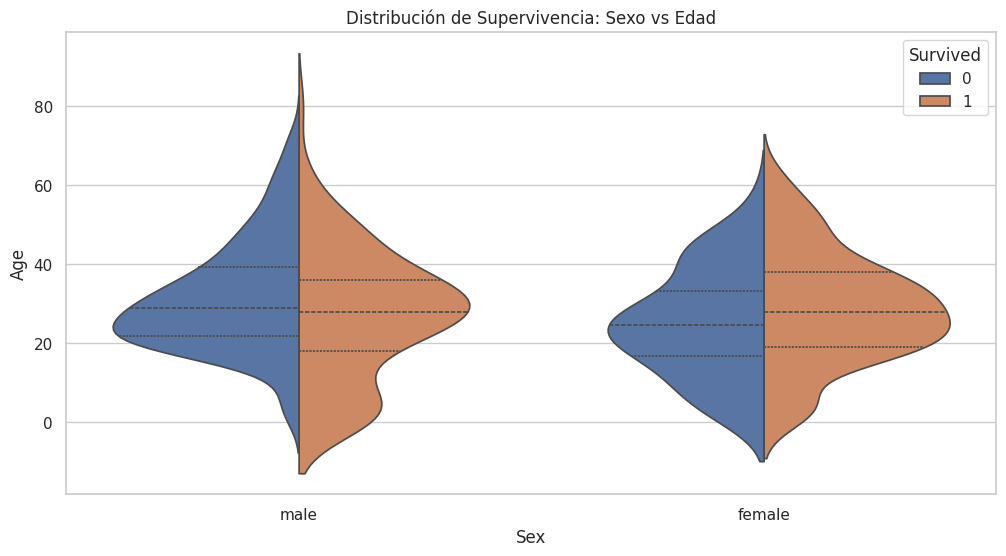

In [59]:
# 1. Definimos quiénes son niños (menores de 16 años por ejemplo)
train_data['IsChild'] = train_data['Age'] < 16

# 2. Gráfico de distribución (Violin Plot)
# El ancho muestra dónde se concentra la mayoría de la gente
plt.figure(figsize=(12, 6))
sns.violinplot(data=train_data, x="Sex", y="Age", hue="Survived", split=True, inner="quart")
plt.title("Distribución de Supervivencia: Sexo vs Edad")
plt.show()

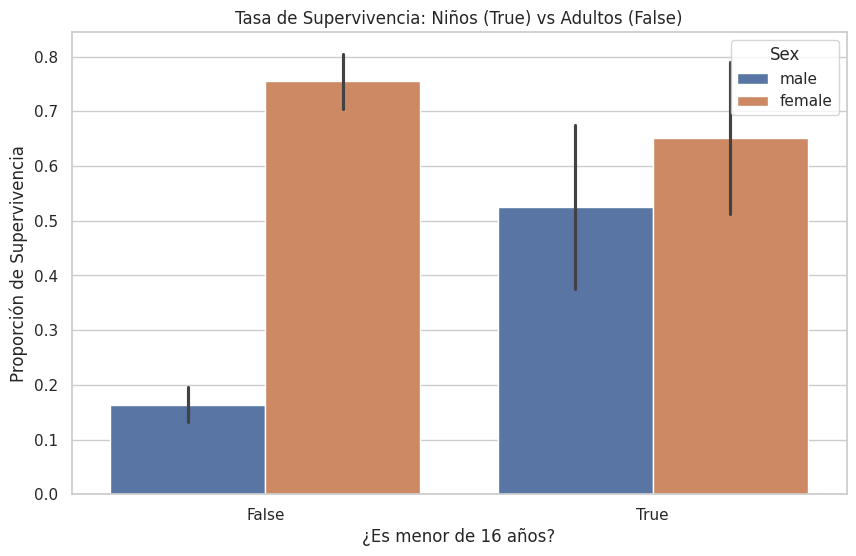

In [60]:


# 3. Gráfico de barras específico para Niños y Género
plt.figure(figsize=(10, 6))
sns.barplot(data=train_data, x="IsChild", y="Survived", hue="Sex")
plt.title("Tasa de Supervivencia: Niños (True) vs Adultos (False)")
plt.xlabel("¿Es menor de 16 años?")
plt.ylabel("Proporción de Supervivencia")
plt.show()

Explicación: El instinto humano y las órdenes en el Titanic fueron "mujeres y niños primero". Al cruzar la edad con el género, validamos si esta regla se cumplió estadísticamente.
Ejemplo: Al observar el gráfico de barras, verás que los niños varones (IsChild: True, Sex: male) tienen una probabilidad de sobrevivir mucho más alta que los hombres adultos, confirmando que la edad "protegió" a los varones jóvenes que de otro modo habrían tenido una tasa de supervivencia muy baja.

¿Qué observar en los resultados?
Mujeres: La supervivencia es alta independientemente de si son niñas o adultas (aunque las niñas tienen una ligera ventaja adicional).

Hombres: Hay una diferencia abismal. Si eres hombre adulto, la tasa es muy baja; si eres niño, tus probabilidades suben drásticamente.

El "hueco" en los hombres: Verás que la curva de hombres fallecidos es muy gruesa entre los 20 y 40 años, que fue el grupo con menor prioridad.

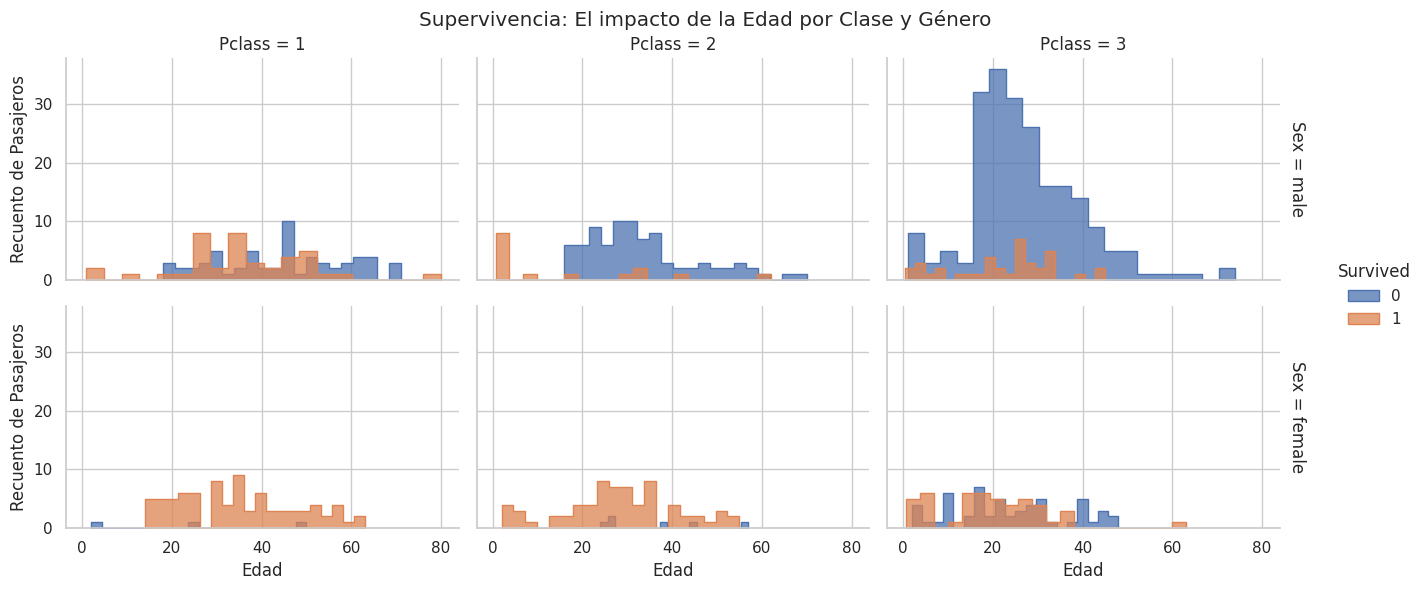

In [61]:
# Crear una cuadrícula de gráficos (FacetGrid)
g = sns.FacetGrid(train_data, col="Pclass", row="Sex", hue="Survived", margin_titles=True, height=3, aspect=1.5)

# Aplicar un histograma a cada panel
g.map(sns.histplot, "Age", element="step", bins=20)

# Añadir leyenda y ajustar títulos
g.add_legend()
g.set_axis_labels("Edad", "Recuento de Pasajeros")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Supervivencia: El impacto de la Edad por Clase y Género")
plt.show()

Visualización: Supervivencia por Clase, Género y Edad
Explicación: Este gráfico genera una matriz de paneles. Cada panel muestra la distribución de edades de los que sobrevivieron (azul) y los que no (naranja), organizados por filas para el género y columnas para la clase social.
Aquí analizamos la intersección de todas las variables críticas. Es el nivel máximo de detalle para entender por qué el modelo de Random Forest toma ciertas decisiones.
Ejemplo: Verás que en la 2ª Clase, la regla de "niños primero" fue casi perfecta para los varones: casi todos los niños sobrevivieron, mientras que casi todos los adultos fallecieron. En cambio, en la 3ª Clase, las barras de fallecidos (naranja) son altas incluso en edades tempranas.
Hallazgos finales del análisis gráfico:

*   El "Escudo" de la 1ª Clase: Si eras mujer o niño en primera clase, tu probabilidad de supervivencia era casi total.
*   La Tragedia de la 3ª Clase: El género y la edad ayudaban, pero la ubicación en el barco (clase) limitaba drásticamente el acceso a los botes
*   Varones de 2ª Clase: Es el grupo donde la edad es más determinante: los niños se salvaron, los adultos no.
